In [1]:
import pandas as pd
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import absolute
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

In [ ]:
#preprocessing the data
df1=pd.read_csv('/Users/melanyalegre/Documents/International Business/4th year/Data Analytics/Data Science/DS_assignment_data - Copy (1).csv')
#features
y=df1['LOAN_DEFAULT']
X=df1.drop('LOAN_DEFAULT',axis=1)
X=pd.get_dummies(X,drop_first=True)
#normalizing the data
columns=X.columns
scaler=MinMaxScaler()
X=scaler.fit_transform(X)
X=pd.DataFrame(X,columns=columns)

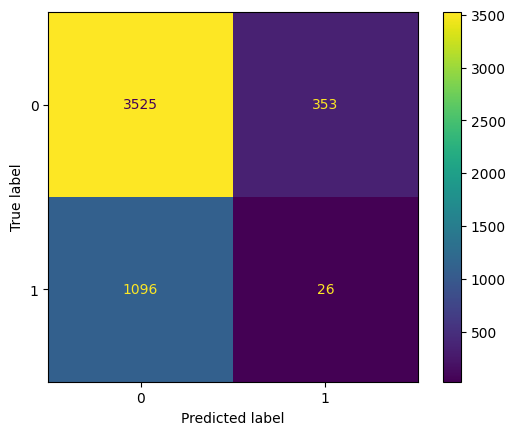

In [4]:
#prediction
rf=RandomForestClassifier(n_estimators=100,random_state=69)
y_pred=cross_val_predict(rf,X,y,cv=5)

cm=confusion_matrix(y,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()



In [5]:
accuracy=(cm.diagonal().sum())/cm.sum()
print('Accuracy:',accuracy)

Accuracy: 0.7102


In [6]:
rf.fit(X,y)
feature_importances= rf.feature_importances_

importance_data=pd.DataFrame({
    'Feature':X.columns,
    'Importance':feature_importances
})

importance_data=importance_data.sort_values(by='Importance',ascending=False)
print((importance_data).head(10))

                            Feature  Importance
3                               LTV    0.058687
1                  DISBURSED_AMOUNT    0.054779
0                          UNIQUEID    0.050782
5                CURRENT_PINCODE_ID    0.049615
2                        ASSET_COST    0.048562
4                         BRANCH_ID    0.029080
12                PERFORM_CNS_SCORE    0.015351
18             PRI_DISBURSED_AMOUNT    0.013098
2928  EMPLOYMENT_TYPE_Self employed    0.012371
16              PRI_CURRENT_BALANCE    0.012041


In [11]:
n_estimators=np.arange(start=50,stop=151,step=25)
max_depth=np.arange(start=10,stop=51,step=10)
min_samples_split=np.arange(start=2,stop=11,step=2)
max_features=[None,'sqrt','log2']

random_grid= {'n_estimators':n_estimators,
              'max_depth':max_depth,
              'min_samples_split':min_samples_split,
              'max_features':max_features,}

rf_random=RandomizedSearchCV(estimator=rf,
                             param_distributions=random_grid,
                             n_iter=20,
                             cv=5,
                             random_state=69)
rf_random.fit(X,y)
rf_random.best_params_

{'n_estimators': np.int64(150),
 'min_samples_split': np.int64(4),
 'max_features': 'log2',
 'max_depth': np.int64(30)}

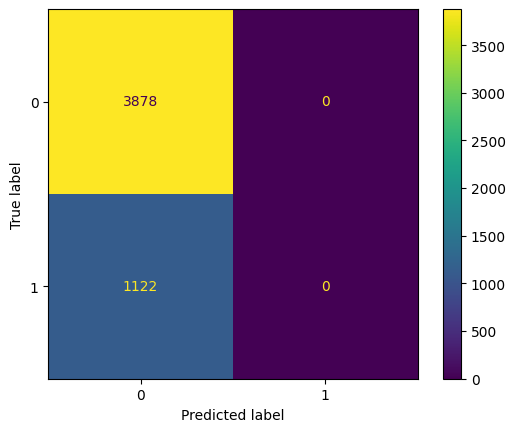

Accuracy: 0.7756


In [15]:
rf=RandomForestClassifier(n_estimators=150,
                          min_samples_split=4,
                          max_features='log2',
                          max_depth=30,
                          random_state=69)
y_pred=cross_val_predict(rf,X,y,cv=5)

cm=confusion_matrix(y,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

accuracy=(cm.diagonal().sum())/cm.sum()
print('Accuracy:',accuracy)